In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [9]:
data = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [31]:
scaled_data[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

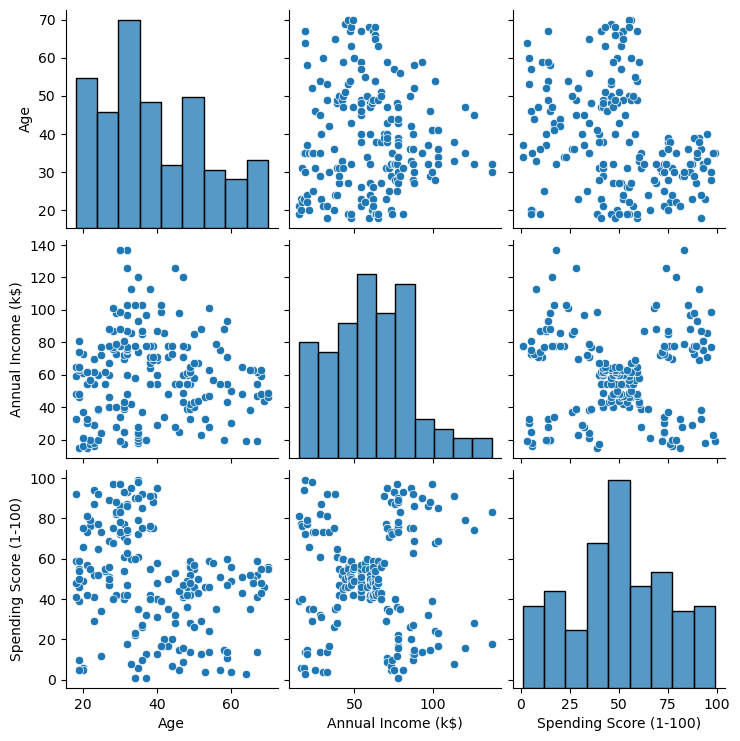

In [33]:
sns.pairplot(data)
plt.show()

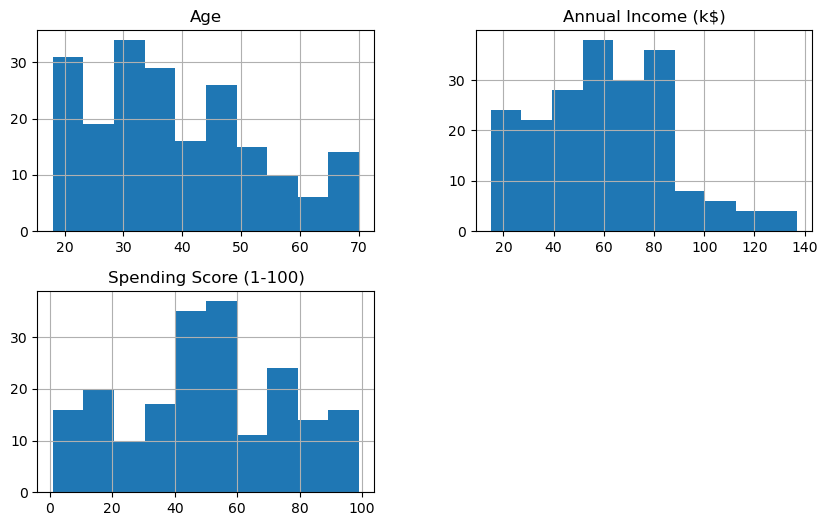

In [34]:
data.hist(figsize=(10,6))
plt.show()

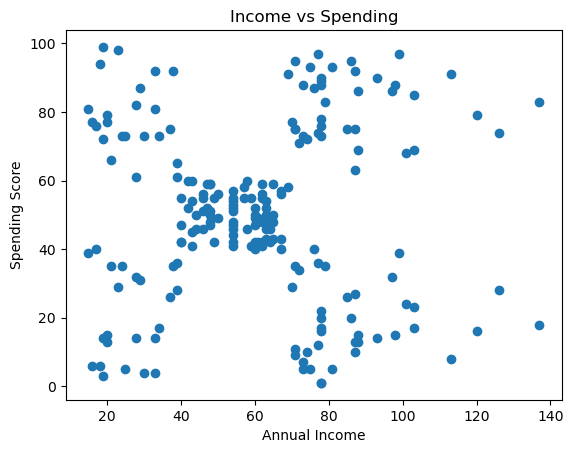

In [35]:
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Income vs Spending')
plt.show()

In [36]:
from sklearn.cluster import KMeans

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

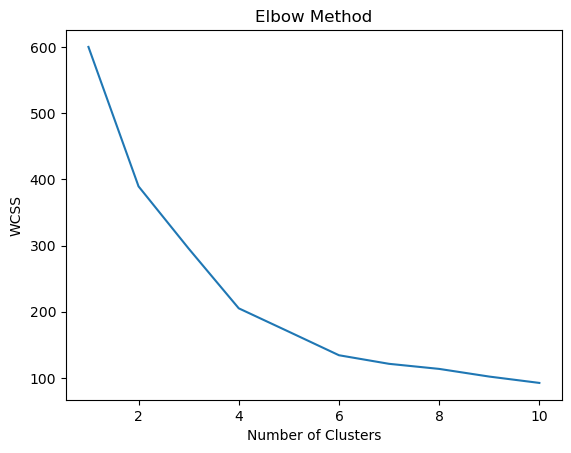

In [37]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [38]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [39]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,2
1,2,0,21,15,81,2
2,3,1,20,16,6,3
3,4,1,23,16,77,2
4,5,1,31,17,40,2


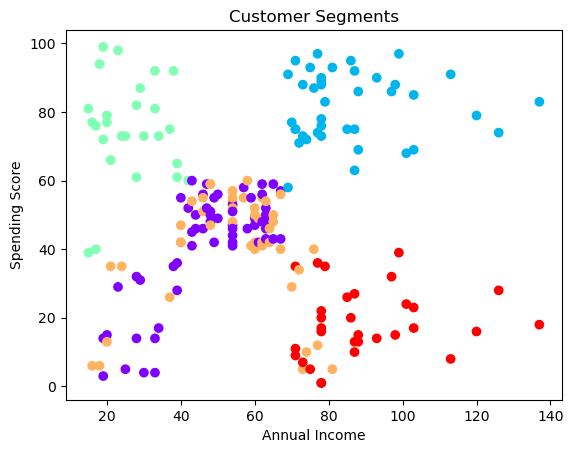

In [40]:
plt.scatter(data['Annual Income (k$)'], 
            data['Spending Score (1-100)'], 
            c=df['Cluster'], cmap='rainbow')

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

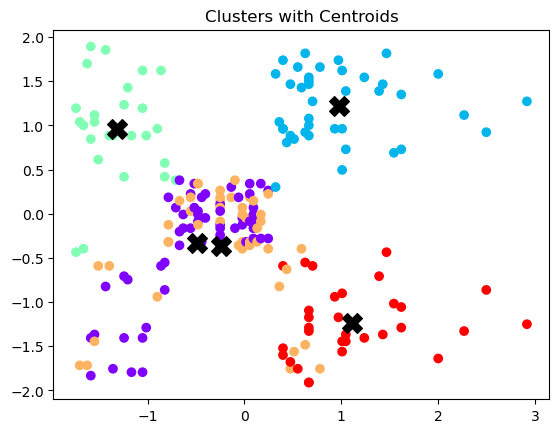

In [41]:
centroids = kmeans.cluster_centers_

plt.scatter(scaled_data[:,1], scaled_data[:,2], c=df['Cluster'], cmap='rainbow')
plt.scatter(centroids[:,1], centroids[:,2], s=200, c='black', marker='X')

plt.title('Clusters with Centroids')
plt.show()

In [42]:
df.groupby('Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,68.775862,0.568966,55.275862,47.620690,41.706897
1,161.025000,0.550000,32.875000,86.100000,81.525000
2,23.461538,0.576923,25.769231,26.115385,74.846154
3,86.377778,0.600000,26.733333,54.311111,40.911111
4,166.870968,0.483871,44.387097,89.774194,18.483871


In [43]:
import sqlite3

# Create connection (this creates a database file)
conn = sqlite3.connect('customer.db')

# Load dataframe into SQL table
df.to_sql('customers', conn, if_exists='replace', index=False)

200

In [44]:
query = """
SELECT 
    Cluster,
    AVG(Age) AS Avg_Age,
    AVG([Annual Income (k$)]) AS Avg_Income,
    AVG([Spending Score (1-100)]) AS Avg_Spending
FROM customers
GROUP BY Cluster
ORDER BY Avg_Income DESC;
"""

result = pd.read_sql(query, conn)
print(result)

   Cluster    Avg_Age  Avg_Income  Avg_Spending
0        4  44.387097   89.774194     18.483871
1        1  32.875000   86.100000     81.525000
2        3  26.733333   54.311111     40.911111
3        0  55.275862   47.620690     41.706897
4        2  25.769231   26.115385     74.846154


In [45]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore', 'Cluster']